<a href="https://colab.research.google.com/github/DGAN45/ML--PROJECTS/blob/main/SVM6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Protein Sequence Analysis with SVM

## Setup and Data Loading

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import files

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### Upload Data Files

In [19]:
upload = files.upload()

Saving cystein_neg_19.txt to cystein_neg_19 (1).txt
Saving cystein_pos_19.txt to cystein_pos_19 (2).txt


### Load Data from Text Files

In [20]:
# Load data
def load_file(path, label):
    data = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                protein = parts[0]
                seq = parts[2]
                data.append([protein, seq, label])
    return data

pos = load_file("cystein_pos_19.txt", 1)
neg = load_file("cystein_neg_19.txt", 0)

df_pos = pd.DataFrame(pos, columns=["protein", "sequence", "label"])
df_neg = pd.DataFrame(neg, columns=["protein", "sequence", "label"])

print("Positive Samples:",len(df_pos))
print("Negative Samples:",len(df_neg))

print("Positive Samples:")
print(df_pos.head())
print("\nNegative Samples:")
print(df_neg.head())

Positive Samples: 1870
Negative Samples: 9279
Positive Samples:
  protein                                 sequence  label
0  P60202  GFYTTGAVRQIFGDYKTTICGKGLSATVTGGQKGRGSRG      1
1  P60202  TTCQSIAFPSKTSASIGSLCADARMYGVLPWNAFPGKVC      1
2  P60202  CADARMYGVLPWNAFPGKVCGSNLLSICKTAEFQMTFHL      1
3  P60202  GQKGRGSRGQHQAHSLERVCHCLGKWLGHPDKFVGITYA      1
4  P60202  KGRGSRGQHQAHSLERVCHCLGKWLGHPDKFVGITYALT      1

Negative Samples:
  protein                                 sequence  label
0  P60202  APFASLVATGLCFFGVALFCGCGHEALTGTEKLIETYFS      0
1  P60202  DKFVGITYALTVVWLLVFACSAVPVYIYFNTWTTCQSIA      0
2  Q6PIC6  FCRQLFGGFSILLWIGAILCFLAYGIQAGTEDDPSGDNL      0
3  Q6PIC6  SGDNLYLGIVLAAVVIITGCFSYYQEAKSSKIMESFKNM      0
4  Q6PIC6  LIGIIVANVPEGLLATVTVCLTLTAKRMARKNCLVKNLE      0


### Balance Dataset

In [21]:
# Find minimum size
n = min(len(df_pos), len(df_neg))

# Take equal samples
df_pos_sample = df_pos.sample(n=n, random_state=42)
df_neg_sample = df_neg.sample(n=n, random_state=42)

# Check
print("Balanced Positive:", len(df_pos_sample))
print("Balanced Negative:", len(df_neg_sample))

Balanced Positive: 1870
Balanced Negative: 1870


## Feature Engineering

In [22]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

def extract_features(seq):
    features = []
    for aa in amino_acids:
        features.append(seq.count(aa) / len(seq))
    center = len(seq) // 2
    features.append(1 if seq[center] == 'C' else 0) # Check for Cysteine at center
    return features

df = pd.concat([df_pos_sample, df_neg_sample]).reset_index(drop=True)

X = np.array([extract_features(s) for s in df["sequence"]])
y = df["label"].values

print("Feature shape:", X.shape)

Feature shape: (3740, 21)


### Scale Features

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Model Training and Evaluation

### Define and Cross-Validate SVM Model

In [24]:
# Model
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation
scores = cross_val_score(model, X_scaled, y, cv=cv)

print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Fold Accuracies: [0.62032086 0.64304813 0.63903743 0.58957219 0.5828877 ]
Mean Accuracy: 0.6149732620320856


### Visualize Cross-Validation Accuracy

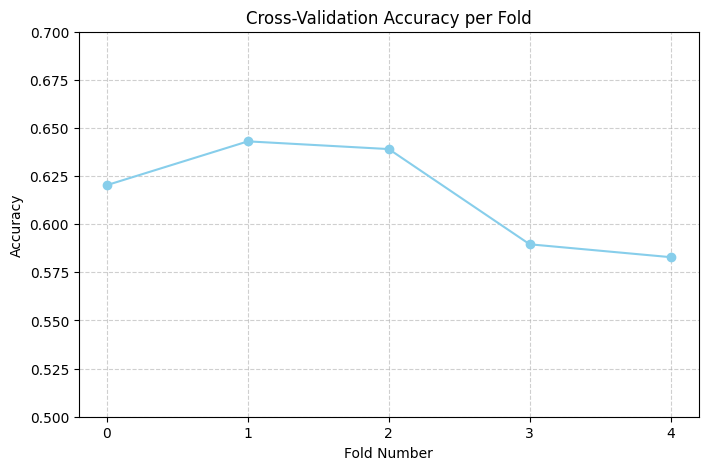

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(scores,marker='o', linestyle='-', color='skyblue')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy per Fold")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(len(scores)))
plt.ylim(0.5, 0.7)
plt.show()

### Detailed Evaluation Metrics (Accuracy, Classification Report, Confusion Matrix)

Tuned Model Accuracy: 0.6449197860962567

Tuned Model Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.61      0.63      1870
           1       0.64      0.68      0.66      1870

    accuracy                           0.64      3740
   macro avg       0.65      0.64      0.64      3740
weighted avg       0.65      0.64      0.64      3740



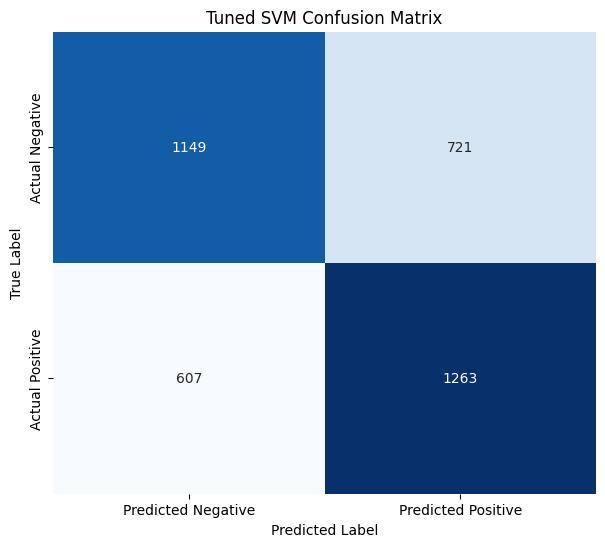

In [26]:
y_pred_tuned = cross_val_predict(model, X_scaled, y, cv=5)

print("Tuned Model Accuracy:", accuracy_score(y, y_pred_tuned))
print("\nTuned Model Classification Report:\n")
print(classification_report(y, y_pred_tuned))

# Visualize the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y, y_pred_tuned)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned SVM Confusion Matrix")
plt.show()

The model achieved an overall accuracy of approximately 64.5%. For class 0 (negative samples), the model has a precision of 65%, a recall of 61%, and an F1-score of 63%. For class 1 (positive samples), the model has a precision of 64%, a recall of 68%, and an F1-score of 66%. The model's performance is relatively balanced between the two classes.

According to the confusion matrix:
*   1149 true negatives (correctly predicted as class 0)
*   721 false positives (incorrectly predicted as class 1 when actually class 0)
*   607 false negatives (incorrectly predicted as class 0 when actually class 1)
*   1263 true positives (correctly predicted as class 1)

### Additional Metrics (Precision, F1 Score)

In [27]:
# Cross-validation predictions
y_pred_metrics = cross_val_predict(model, X_scaled, y, cv=5)

# Metrics
acc = accuracy_score(y, y_pred_metrics)
prec = precision_score(y, y_pred_metrics)
f1 = f1_score(y, y_pred_metrics)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.6449
Precision: 0.6366
F1 Score: 0.6554


## Prediction and Analysis of PTM Proteins

Predicted PTM proteins: ['Q91Z53' 'Q8BH59' 'P14094' 'Q812A2' 'P09411' 'Q8R1C0' 'P60710' 'P15105'
 'O54828' 'Q9ERT9'] ...
Total Predicted PTM proteins: 1013


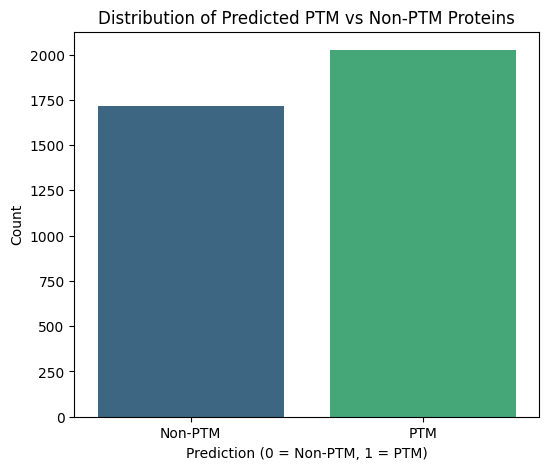

In [29]:
# Explicitly fit the model to the entire dataset (necessary for .predict() calls outside of cross_val_predict)
model.fit(X_scaled, y)

# Make predictions on the scaled data using the fitted model
df["prediction"] = model.predict(X_scaled)

# Identify unique proteins predicted as PTM (label 1)
ptm_proteins = df[df["prediction"] == 1]["protein"].unique()

print("Predicted PTM proteins:", ptm_proteins[:10], "...") # Print first 10 for brevity
print("Total Predicted PTM proteins:", len(ptm_proteins))

# Visualize the distribution of predicted PTM vs Non-PTM proteins
plt.figure(figsize=(6, 5))
sns.countplot(x=df["prediction"], palette='viridis')
plt.title("Distribution of Predicted PTM vs Non-PTM Proteins")
plt.xlabel("Prediction (0 = Non-PTM, 1 = PTM)")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-PTM', 'PTM'])
plt.show()

## Visualization: PCA and SVM Decision Boundary

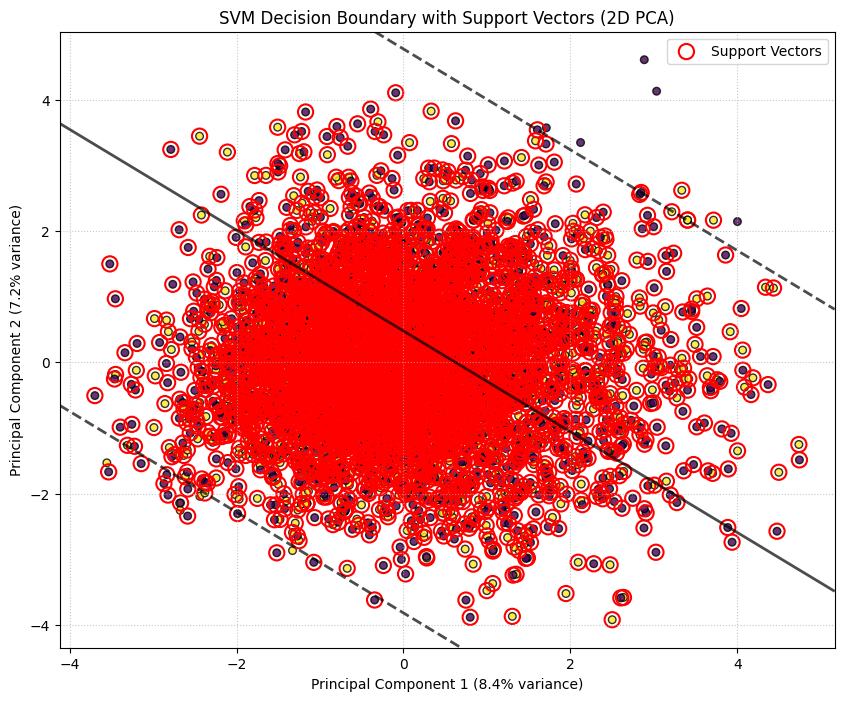

In [30]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Train a *new* linear SVM for visualization on the 2D data
svm_vis = SVC(kernel='linear')
svm_vis.fit(X_2d, y)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='viridis', s=30, alpha=0.8, edgecolor='k')

# Plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_vis.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.7, linestyles=['--', '-', '--'],
           linewidths=2) # Added levels for margins

# Highlight support vectors
ax.scatter(svm_vis.support_vectors_[:, 0], svm_vis.support_vectors_[:, 1],
           s=120, linewidth=1.5, facecolors='none', edgecolors='red', label='Support Vectors')

plt.title("SVM Decision Boundary with Support Vectors (2D PCA)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

From this project, we have gained a comprehensive understanding of protein sequence analysis for predicting Post-Translational Modifications (PTMs) using an SVM model.